# Phase 4b: focused reliability redesign

This notebook preserves Phase 4 and tests why the original residual + MC-Dropout
logic failed before changing any detector. All redesign thresholds are calibrated
on clean validation trajectories only. No MPC is implemented here.

In [1]:
import json
import sys
from dataclasses import replace
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score

get_ipython().run_line_magic("matplotlib", "inline")

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from motor_model import DCMotorParams, simulate_motor
from reliability import (
    REDESIGN_STATE_NAMES,
    calibrate_cusum,
    classify_redesign,
    cusum_monitor,
    guarded_predict,
    load_lstm_model,
    mc_dropout_predict,
    multistep_error,
    temporal_residual_features,
)

SEED = 2026
FAULT_START = 4.0
FAULT_END = 5.5
EWMA_ALPHA = 0.10
ROLLING_WINDOW = 20
MISMATCH_HORIZON = 15
MISMATCH_ROLLING_WINDOW = 20
PERCENTILES = (95.0, 97.5, 99.0, 99.5, 99.9)
TARGET_VALIDATION_FAR = 0.01
MC_PASSES = (10, 20, 30, 50)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))

data = np.load(project_root / "data" / "processed" / "dc_motor_lstm_dataset.npz")
model, model_config = load_lstm_model(
    project_root / "results" / "lstm_model_weights.pt",
    project_root / "results" / "configs" / "lstm_model_config.json",
)
old_config = json.loads(
    (project_root / "results" / "configs" / "reliability_config.json").read_text()
)
normalization = model_config["normalization"]
input_mean = np.asarray(normalization["input_mean"])
input_std = np.asarray(normalization["input_std"])
target_mean = float(normalization["target_mean"][0])
target_std = float(normalization["target_std"][0])
window_length = int(model_config["window_length"])
timestep = float(data["timestep"])
time = data["time"].astype(float)
test_ids = data["split_run_ids_test"].astype(int)
validation_ids = data["split_run_ids_validation"].astype(int)

assert set(test_ids).isdisjoint(validation_ids)
print(f"Validation runs: {validation_ids.tolist()}; unseen test runs: {test_ids.tolist()}")
print(f"Old thresholds kept fixed for diagnosis: tau_r={old_config['tau_r']:.4f}, tau_sigma={old_config['tau_sigma']:.6f}")

Validation runs: [3, 9, 11, 16, 19, 23]; unseen test runs: [8, 15, 17, 22, 25, 28]
Old thresholds kept fixed for diagnosis: tau_r=0.7244, tau_sigma=0.023963


## Experiment helpers and held-out scenarios

Sensor faults are injected into every held-out test trajectory. Load and
parameter cases use the held-out voltage traces but are newly simulated.

In [2]:
def make_windows(voltage, measured):
    features = np.column_stack((voltage, measured))
    windows = np.stack(
        [features[start : start + window_length] for start in range(len(features) - window_length)]
    )
    return ((windows - input_mean) / input_std).astype(np.float32)


@torch.no_grad()
def deterministic_batch(voltage, measured, batch_size=512):
    all_windows = np.concatenate(
        [make_windows(voltage[row], measured[row]) for row in range(len(voltage))]
    )
    predictions = []
    for start in range(0, len(all_windows), batch_size):
        batch = torch.from_numpy(all_windows[start : start + batch_size])
        predictions.append(model(batch).cpu().numpy()[:, 0])
    return (np.concatenate(predictions) * target_std + target_mean).reshape(
        len(voltage), -1
    )


def mc_batch(voltage, measured, passes, seed):
    all_windows = np.concatenate(
        [make_windows(voltage[row], measured[row]) for row in range(len(voltage))]
    )
    torch.manual_seed(seed)
    mean, variance = mc_dropout_predict(model, all_windows, passes=passes, batch_size=256)
    shape = (len(voltage), len(time) - window_length)
    return (
        (mean.numpy()[:, 0] * target_std + target_mean).reshape(shape),
        (variance.numpy()[:, 0] * target_std**2).reshape(shape),
    )


def overlap_coefficient(first, second, bins=80):
    first, second = np.asarray(first), np.asarray(second)
    low, high = min(first.min(), second.min()), max(first.max(), second.max())
    if np.isclose(low, high):
        return 1.0
    first_hist, edges = np.histogram(first, bins=bins, range=(low, high), density=True)
    second_hist, _ = np.histogram(second, bins=edges, density=True)
    return float(np.minimum(first_hist, second_hist).sum() * np.diff(edges)[0])


def detection_latency(flagged, active):
    latencies = []
    target_time = time[window_length:]
    for row in range(len(flagged)):
        detections = np.flatnonzero(flagged[row] & active[row])
        if len(detections):
            latencies.append(float(target_time[detections[0]] - FAULT_START))
    return float(np.mean(latencies)) if latencies else None


def binary_summary(labels, predictions):
    labels = np.asarray(labels, dtype=bool).ravel()
    predictions = np.asarray(predictions, dtype=bool).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    return {
        "false_alarm_rate": float(np.mean(predictions[~labels])),
        "detection_rate": float(np.mean(predictions[labels])),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def sampled_signal(samples):
    return lambda instant: float(np.interp(instant, time, samples))


nominal = DCMotorParams()
shifted = replace(
    nominal,
    resistance=1.15 * nominal.resistance,
    inductance=0.85 * nominal.inductance,
    back_emf_constant=1.15 * nominal.back_emf_constant,
    torque_constant=0.85 * nominal.torque_constant,
    inertia=1.15 * nominal.inertia,
    viscous_friction=1.15 * nominal.viscous_friction,
    coulomb_friction=1.15 * nominal.coulomb_friction,
)
scenario_rng = np.random.default_rng(SEED + 200)
base_voltage = data["voltage"][test_ids].astype(float)
base_true = data["y_true"][test_ids].astype(float)
base_measured = data["y_measured"][test_ids].astype(float)
fault_mask = time >= FAULT_START
dropout_mask = (time >= FAULT_START) & (time < FAULT_END)


def simulate_changed(kind):
    true_rows = []
    for voltage_samples in base_voltage:
        voltage_function = sampled_signal(voltage_samples)
        if kind == "load":
            load = lambda instant: 0.03 if instant < FAULT_START else 0.15
            _, states = simulate_motor(
                voltage_function,
                load,
                simulation_time=float(data["duration"]),
                timestep=timestep,
                params=nominal,
            )
        else:
            load = lambda _instant: 0.03
            _, pre = simulate_motor(
                voltage_function,
                load,
                simulation_time=FAULT_START,
                timestep=timestep,
                params=nominal,
            )
            _, post = simulate_motor(
                lambda instant: voltage_function(instant + FAULT_START),
                load,
                simulation_time=float(data["duration"]) - FAULT_START,
                timestep=timestep,
                params=shifted,
                initial_state=tuple(pre[-1]),
            )
            states = np.vstack((pre, post[1:]))
        true_rows.append(states[:, 1])
    true_rows = np.asarray(true_rows)
    measured_rows = true_rows + scenario_rng.normal(0.0, 0.25, true_rows.shape)
    return true_rows, measured_rows


load_true, load_measured = simulate_changed("load")
parameter_true, parameter_measured = simulate_changed("parameters")

scenarios = {}


def add_scenario(name, title, true, measured, active, expected_state):
    scenarios[name] = {
        "title": title,
        "voltage": base_voltage.copy(),
        "true": np.asarray(true),
        "measured": np.asarray(measured),
        "active": np.broadcast_to(active, np.asarray(measured).shape).copy(),
        "expected_state": expected_state,
    }


add_scenario("clean", "Clean held-out operation", base_true, base_measured, False, 0)
gaussian = base_measured.copy()
gaussian[:, fault_mask] += scenario_rng.normal(0.0, 2.0, gaussian[:, fault_mask].shape)
add_scenario("gaussian_noise", "Added Gaussian sensor noise (2 rad/s)", base_true, gaussian, fault_mask, 1)
small_bias = base_measured.copy(); small_bias[:, fault_mask] += 1.0
add_scenario("small_bias", "Small sensor bias (+1 rad/s)", base_true, small_bias, fault_mask, 1)
large_bias = base_measured.copy(); large_bias[:, fault_mask] += 6.0
add_scenario("large_bias", "Large sensor bias (+6 rad/s)", base_true, large_bias, fault_mask, 1)
drift = base_measured + np.clip((time - FAULT_START) / 4.0, 0.0, 1.0)[None, :] * 6.0
add_scenario("gradual_drift", "Gradual sensor drift (0 to +6 rad/s)", base_true, drift, fault_mask, 1)
dropout = base_measured.copy(); dropout[:, dropout_mask] = 0.0
add_scenario("temporary_dropout", "Temporary dropout to zero", base_true, dropout, dropout_mask, 1)
add_scenario("load_step", "Load step (0.03 to 0.15 N m)", load_true, load_measured, fault_mask, 2)
add_scenario("parameter_variation", "Sudden moderate parameter variation", parameter_true, parameter_measured, fault_mask, 2)
combined = parameter_measured.copy(); combined[:, fault_mask] += 2.0
add_scenario("combined_fault", "Parameter variation + sensor bias", parameter_true, combined, fault_mask, 1)

print("Final scenarios:", list(scenarios))
print(
    "Normalized sensor magnitudes:",
    {"small_bias": 1.0 / input_std[1], "large_bias": 6.0 / input_std[1], "noise_std": 2.0 / input_std[1]},
)

Final scenarios: ['clean', 'gaussian_noise', 'small_bias', 'large_bias', 'gradual_drift', 'temporary_dropout', 'load_step', 'parameter_variation', 'combined_fault']
Normalized sensor magnitudes: {'small_bias': np.float64(0.073335578293408), 'large_bias': np.float64(0.44001346976044803), 'noise_std': np.float64(0.146671156586816)}


## 1. Diagnose the unchanged Phase-4 signals

The saved 99th-percentile thresholds are used unchanged here. This separates
diagnosis from redesign and exposes transient adaptation, persistence, and
distribution overlap.

In [3]:
original = {}
deterministic = {}
for scenario_index, (name, scenario) in enumerate(scenarios.items()):
    deterministic_mean = deterministic_batch(scenario["voltage"], scenario["measured"])
    mean, variance = mc_batch(
        scenario["voltage"], scenario["measured"], 10, SEED + 300 + scenario_index
    )
    original[name] = {
        "mean": mean,
        "variance": variance,
        "signed": scenario["measured"][:, window_length:] - mean,
    }
    original[name]["absolute"] = np.abs(original[name]["signed"])
    deterministic[name] = {
        "mean": deterministic_mean,
        "signed": scenario["measured"][:, window_length:] - deterministic_mean,
    }

target_time = time[window_length:]
clean_residual_distribution = original["clean"]["absolute"].ravel()
clean_variance_distribution = original["clean"]["variance"].ravel()
diagnosis_rows = []
for name, scenario in scenarios.items():
    active = scenario["active"][:, window_length:]
    sample_mask = np.ones_like(active) if name == "clean" else active
    residual = original[name]["absolute"][sample_mask]
    variance = original[name]["variance"][sample_mask]
    late = np.broadcast_to(target_time >= FAULT_START + 0.5, active.shape) & active
    first = np.broadcast_to(
        (target_time >= FAULT_START) & (target_time < FAULT_START + 0.2), active.shape
    ) & active
    residual_ks = ks_2samp(clean_residual_distribution, residual)
    variance_ks = ks_2samp(clean_variance_distribution, variance)
    diagnosis_rows.append(
        {
            "scenario": name,
            "mean_absolute_residual": float(np.mean(residual)),
            "residual_exceedance_rate": float(np.mean(residual > old_config["tau_r"])),
            "first_0.2s_residual_rate": float(np.mean(original[name]["absolute"][first] > old_config["tau_r"])) if first.any() else None,
            "late_residual_rate": float(np.mean(original[name]["absolute"][late] > old_config["tau_r"])) if late.any() else None,
            "mean_mc_variance": float(np.mean(variance)),
            "variance_exceedance_rate": float(np.mean(variance > old_config["tau_sigma"])),
            "residual_clean_overlap": overlap_coefficient(clean_residual_distribution, residual),
            "variance_clean_overlap": overlap_coefficient(clean_variance_distribution, variance),
            "residual_ks_statistic": float(residual_ks.statistic),
            "residual_ks_pvalue": float(residual_ks.pvalue),
            "variance_ks_statistic": float(variance_ks.statistic),
            "variance_ks_pvalue": float(variance_ks.pvalue),
            "original_detection_latency_seconds": detection_latency(
                (original[name]["absolute"] > old_config["tau_r"])
                | (original[name]["variance"] > old_config["tau_sigma"]),
                active,
            ) if active.any() else None,
        }
    )

diagnosis_df = pd.DataFrame(diagnosis_rows)
display(diagnosis_df.round(4))

,scenario,mean_absolute_residual,residual_exceedance_rate,first_0.2s_residual_rate,late_residual_rate,mean_mc_variance,variance_exceedance_rate,residual_clean_overlap,variance_clean_overlap,residual_ks_statistic,residual_ks_pvalue,variance_ks_statistic,variance_ks_pvalue,original_detection_latency_seconds
0,clean,0.2308,0.0135,NaN,NaN,0.0048,0.0168,1.0000,1.0000,0.0000,1.0000,0.0000,1.000,NaN
1,gaussian_noise,1.8017,0.7443,0.7540,0.7457,0.0571,0.5864,0.2527,0.2911,0.7490,0.0000,0.7107,0.000,0.0033
2,small_bias,0.2328,0.0154,0.0714,0.0142,0.0046,0.0160,0.9678,0.9644,0.0092,0.9675,0.0363,0.001,0.2567
3,large_bias,0.2559,0.0260,0.4683,0.0144,0.0078,0.0587,0.9721,0.9417,0.0237,0.0780,0.0615,0.000,0.0000
4,gradual_drift,0.2326,0.0127,0.0079,0.0126,0.0065,0.0454,0.9435,0.9569,0.0084,0.9870,0.0441,0.000,0.5633
5,temporary_dropout,0.7029,0.1022,0.7302,0.0000,0.0364,0.1244,0.9050,0.6935,0.0968,0.0000,0.5786,0.000,0.0000
6,load_step,0.2395,0.0129,0.0238,0.0122,0.0040,0.0046,0.9554,0.9452,0.0307,0.0089,0.0538,0.000,0.9983
7,parameter_variation,0.2316,0.0121,0.0079,0.0118,0.0028,0.0002,0.9462,0.8058,0.0115,0.8398,0.1966,0.000,0.5517
8,combined_fault,0.2364,0.0162,0.1667,0.0120,0.0029,0.0029,0.9716,0.8220,0.0147,0.5554,0.1833,0.000,0.0000


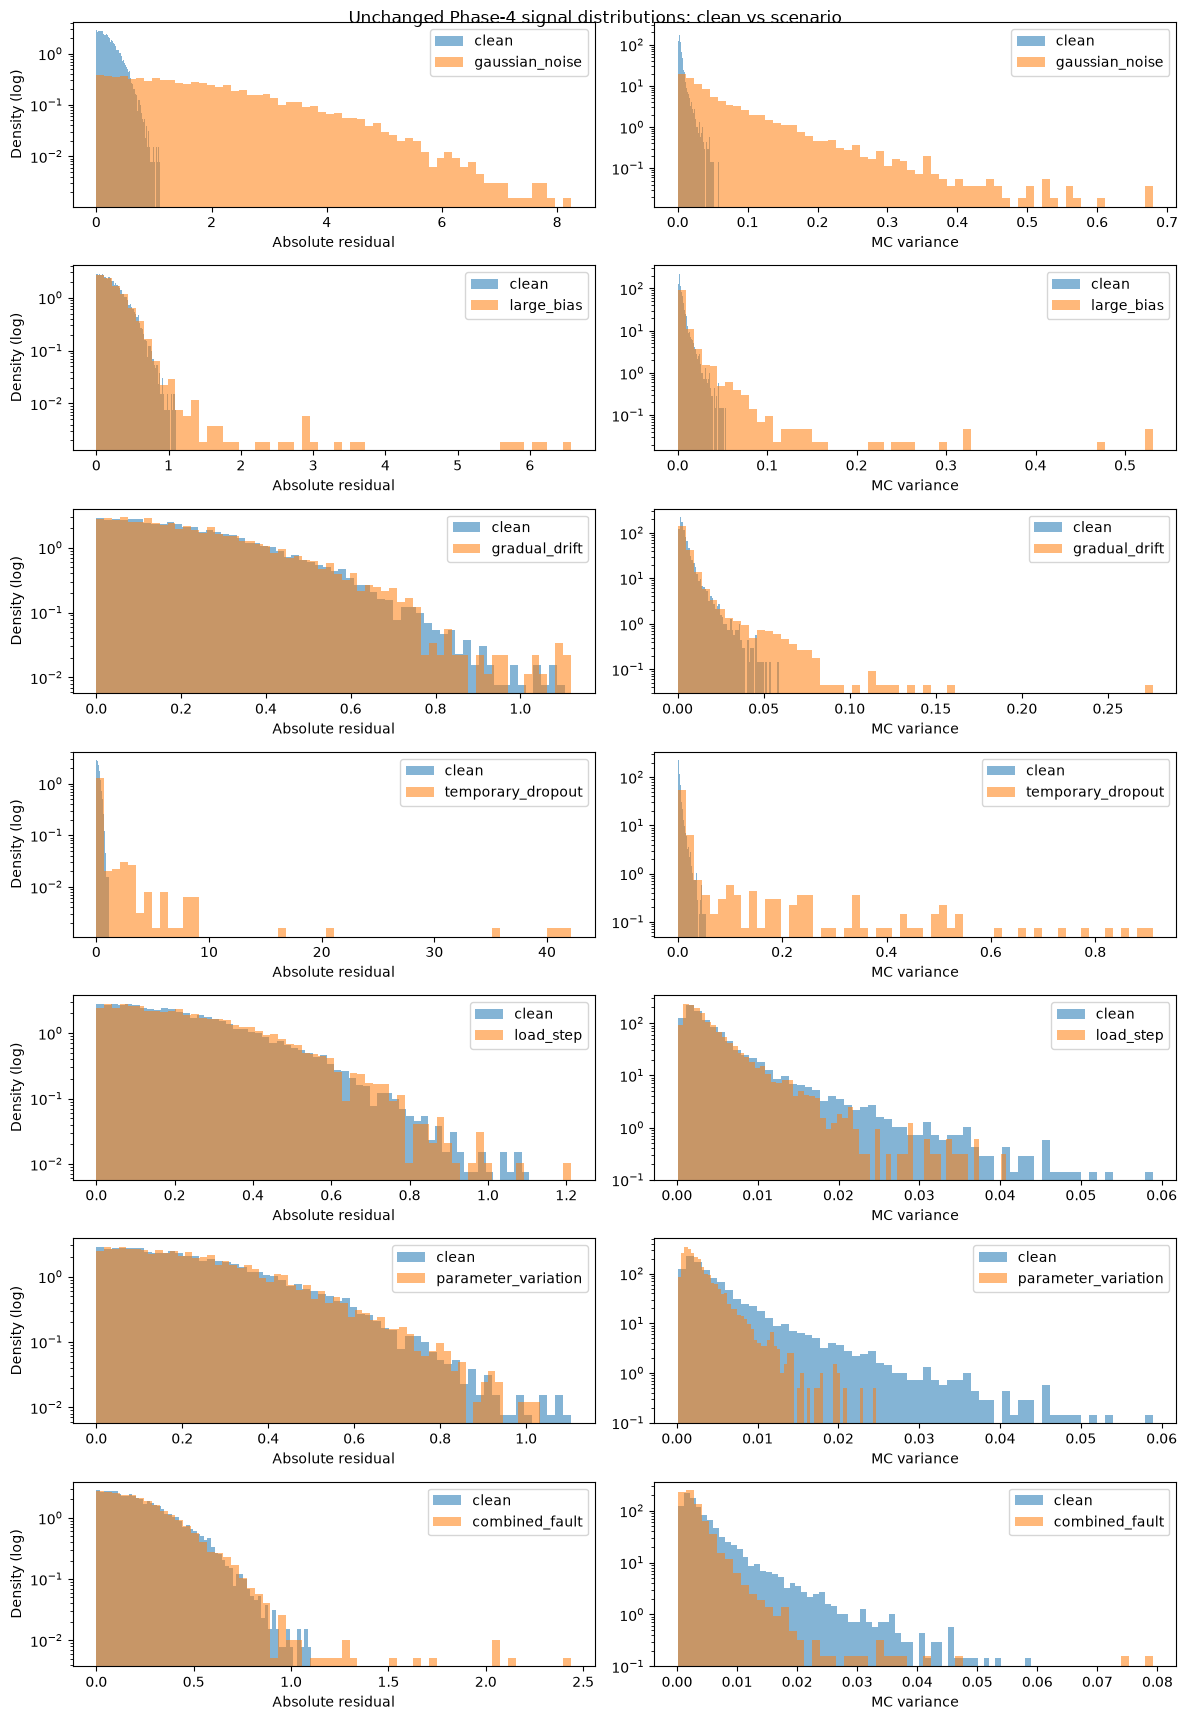

In [4]:
histogram_names = [
    "gaussian_noise", "large_bias", "gradual_drift", "temporary_dropout",
    "load_step", "parameter_variation", "combined_fault",
]
fig, axes = plt.subplots(len(histogram_names), 2, figsize=(12, 2.5 * len(histogram_names)))
for row, name in enumerate(histogram_names):
    active = scenarios[name]["active"][:, window_length:]
    for axis, clean_values, fault_values, label in (
        (axes[row, 0], clean_residual_distribution, original[name]["absolute"][active], "Absolute residual"),
        (axes[row, 1], clean_variance_distribution, original[name]["variance"][active], "MC variance"),
    ):
        axis.hist(clean_values, bins=60, density=True, alpha=0.55, label="clean")
        axis.hist(fault_values, bins=60, density=True, alpha=0.55, label=name)
        axis.set_yscale("log")
        axis.set_xlabel(label)
        axis.legend()
    axes[row, 0].set_ylabel("Density (log)")
fig.suptitle("Unchanged Phase-4 signal distributions: clean vs scenario")
fig.tight_layout()
plots_dir = project_root / "results" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(plots_dir / "reliability_redesign_distributions.png", dpi=160)
plt.show()

## 2–4. Input contamination, temporal residuals, and calibrated CUSUM

Strategy A always feeds measured speed back into the next window. Strategy B
replaces a sample only while its instantaneous residual exceeds the clean guard,
so a clean outlier recovers on the next plausible measurement. CUSUM remains a
temporal monitor and is deliberately not allowed to latch predictor feedback.

In [5]:
validation_voltage = data["voltage"][validation_ids].astype(float)
validation_measured = data["y_measured"][validation_ids].astype(float)
validation_original_mean = deterministic_batch(validation_voltage, validation_measured)
validation_original_signed = validation_measured[:, window_length:] - validation_original_mean
guard_threshold = float(np.percentile(np.abs(validation_original_signed), 99.0))
guard_cusum = calibrate_cusum(validation_original_signed, percentile=99.0, allowance_sigma=0.5)

validation_guarded = guarded_predict(
    model,
    validation_voltage,
    validation_measured,
    normalization,
    window_length,
    guard_threshold,
    None,
)
guarded = {}
temporal = {}
for name, scenario in scenarios.items():
    guarded[name] = guarded_predict(
        model,
        scenario["voltage"],
        scenario["measured"],
        normalization,
        window_length,
        guard_threshold,
        None,
    )
    temporal[name] = {
        key: np.stack(
            [
                temporal_residual_features(row, ROLLING_WINDOW, EWMA_ALPHA, guard_threshold)[key]
                for row in guarded[name]["residual"]
            ]
        )
        for key in ("absolute", "rolling_mean", "rolling_rms", "ewma", "normalized")
    }
    monitors = [
        cusum_monitor(row, guard_cusum["center"], guard_cusum["allowance"], guard_cusum["threshold"])
        for row in guarded[name]["residual"]
    ]
    for key in ("positive", "negative", "score", "alarm"):
        temporal[name][f"cusum_{key}"] = np.stack([monitor[key] for monitor in monitors])

validation_features = [
    temporal_residual_features(row, ROLLING_WINDOW, EWMA_ALPHA, guard_threshold)
    for row in validation_guarded["residual"]
]
validation_ewma = np.concatenate([features["ewma"] for features in validation_features])
validation_monitors = [
    cusum_monitor(row, guard_cusum["center"], guard_cusum["allowance"], guard_cusum["threshold"])
    for row in validation_guarded["residual"]
]
validation_cusum_score = np.concatenate([monitor["score"] for monitor in validation_monitors])

contamination_rows = []
for name in ("small_bias", "large_bias", "gradual_drift", "temporary_dropout"):
    active = scenarios[name]["active"][:, window_length:]
    original_flag = np.abs(deterministic[name]["signed"]) > guard_threshold
    guarded_flag = np.abs(guarded[name]["residual"]) > guard_threshold
    contamination_rows.append(
        {
            "scenario": name,
            "current_input_detection_rate": float(np.mean(original_flag[active])),
            "guarded_input_detection_rate": float(np.mean(guarded_flag[active])),
            "guarded_feedback_fraction": float(np.mean(guarded[name]["substituted"][active])),
            "current_late_mean_abs_residual": float(np.mean(np.abs(deterministic[name]["signed"][:, target_time >= FAULT_START + 0.5]))),
            "guarded_late_mean_abs_residual": float(np.mean(np.abs(guarded[name]["residual"][:, target_time >= FAULT_START + 0.5]))),
        }
    )
contamination_df = pd.DataFrame(contamination_rows)
display(contamination_df.round(4))

,scenario,current_input_detection_rate,guarded_input_detection_rate,guarded_feedback_fraction,current_late_mean_abs_residual,guarded_late_mean_abs_residual
0,small_bias,0.0154,0.1450,0.1450,0.2311,1.2572
1,large_bias,0.0248,0.4960,0.4960,0.2325,3.5146
2,gradual_drift,0.0125,0.0131,0.0131,0.2326,0.2339
3,temporary_dropout,0.1011,1.0000,1.0000,0.3408,7.4755


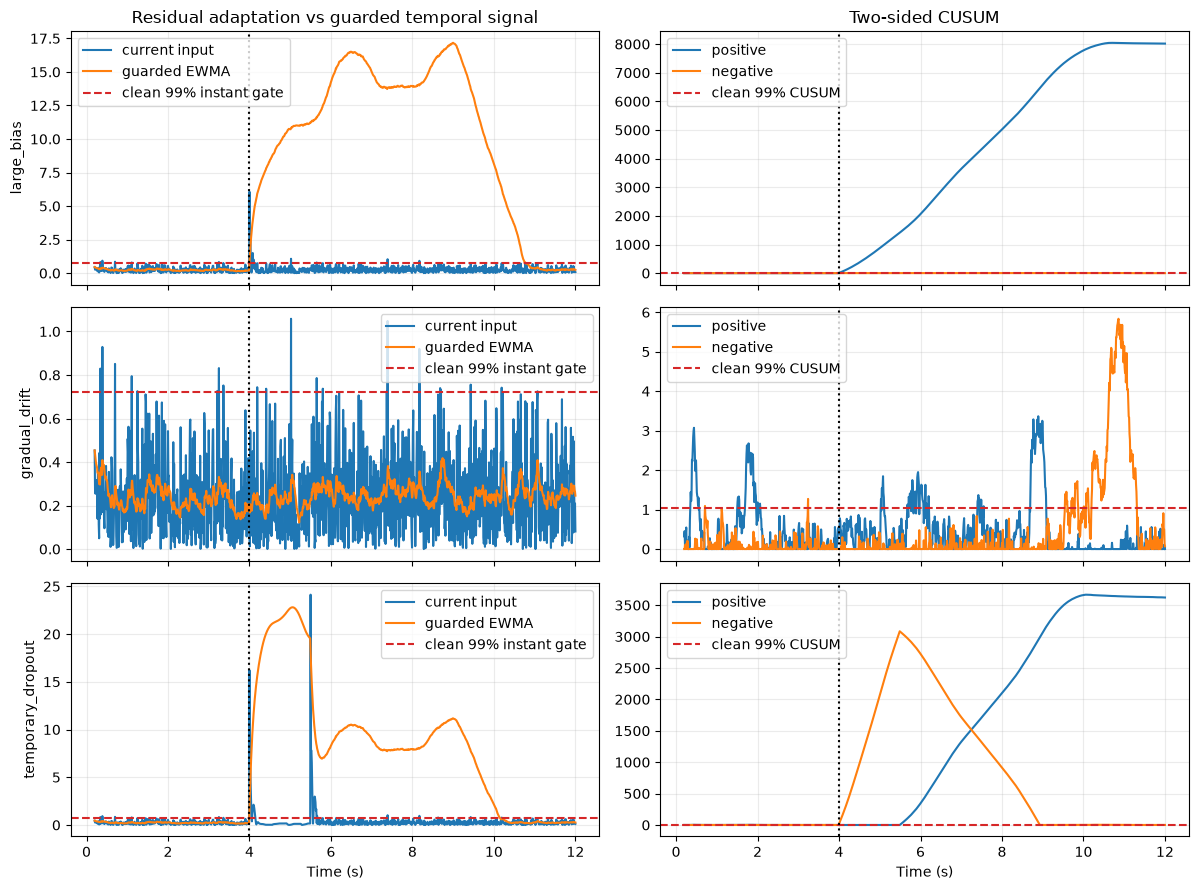

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for row, name in enumerate(("large_bias", "gradual_drift", "temporary_dropout")):
    axes[row, 0].plot(target_time, np.abs(deterministic[name]["signed"][0]), label="current input")
    axes[row, 0].plot(target_time, temporal[name]["ewma"][0], label="guarded EWMA")
    axes[row, 0].axhline(guard_threshold, color="tab:red", linestyle="--", label="clean 99% instant gate")
    axes[row, 1].plot(target_time, temporal[name]["cusum_positive"][0], label="positive")
    axes[row, 1].plot(target_time, temporal[name]["cusum_negative"][0], label="negative")
    axes[row, 1].axhline(guard_cusum["threshold"], color="tab:red", linestyle="--", label="clean 99% CUSUM")
    for axis in axes[row]:
        axis.axvline(FAULT_START, color="black", linestyle=":")
        axis.grid(alpha=0.25)
        axis.legend()
    axes[row, 0].set_ylabel(name)
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
axes[0, 0].set_title("Residual adaptation vs guarded temporal signal")
axes[0, 1].set_title("Two-sided CUSUM")
fig.tight_layout()
fig.savefig(plots_dir / "reliability_redesign_temporal_traces.png", dpi=160)
plt.show()

## 5. Is MC Dropout useful for model uncertainty?

N = 10, 20, 30, and 50 are compared using mean variance, temporal coefficient
of variation, a 20-sample rolling aggregate, KS effect size, overlap, and raw
ROC AUC against clean operation. Tiny p-values alone are not treated as useful
separation because adjacent samples are autocorrelated.

In [7]:
edge_voltage = np.broadcast_to(np.where(time < FAULT_START, 0.0, 12.0), (1, len(time)))
_, edge_states = simulate_motor(
    sampled_signal(edge_voltage[0]),
    lambda _instant: 0.0,
    simulation_time=float(data["duration"]),
    timestep=timestep,
    params=nominal,
)
edge_measured = edge_states[:, 1][None, :] + scenario_rng.normal(0.0, 0.25, edge_voltage.shape)
mc_inputs = {
    "clean": (scenarios["clean"]["voltage"][:1], scenarios["clean"]["measured"][:1]),
    "load_step": (scenarios["load_step"]["voltage"][:1], scenarios["load_step"]["measured"][:1]),
    "parameter_variation": (scenarios["parameter_variation"]["voltage"][:1], scenarios["parameter_variation"]["measured"][:1]),
    "edge_operating_point": (edge_voltage, edge_measured),
}
mc_study_rows = []
for passes in MC_PASSES:
    variances = {}
    for scenario_index, (name, (voltage, measured)) in enumerate(mc_inputs.items()):
        _, variance = mc_batch(voltage, measured, passes, SEED + 500 + 10 * passes + scenario_index)
        variances[name] = variance[0]
    clean_variance = variances["clean"]
    clean_rolling = temporal_residual_features(clean_variance, 20, 0.1)["rolling_mean"]
    for name, variance in variances.items():
        rolling = temporal_residual_features(variance, 20, 0.1)["rolling_mean"]
        if name == "clean":
            ks_statistic, ks_pvalue, overlap, auc = 0.0, 1.0, 1.0, 0.5
        else:
            ks_result = ks_2samp(clean_rolling, rolling)
            ks_statistic, ks_pvalue = float(ks_result.statistic), float(ks_result.pvalue)
            overlap = overlap_coefficient(clean_rolling, rolling)
            auc = float(
                roc_auc_score(
                    np.r_[np.zeros(len(clean_rolling)), np.ones(len(rolling))],
                    np.r_[clean_rolling, rolling],
                )
            )
        mc_study_rows.append(
            {
                "passes": passes,
                "scenario": name,
                "mean_predictive_variance": float(np.mean(variance)),
                "temporal_coefficient_of_variation": float(np.std(variance) / max(np.mean(variance), 1e-12)),
                "rolling_mean_variance": float(np.mean(rolling)),
                "ks_statistic_vs_clean": ks_statistic,
                "ks_pvalue_vs_clean": ks_pvalue,
                "clean_overlap": overlap,
                "raw_auc_vs_clean": auc,
            }
        )
mc_study_df = pd.DataFrame(mc_study_rows)
display(mc_study_df.round(4))

model_mc_rows = mc_study_df[
    mc_study_df["scenario"].isin(["load_step", "parameter_variation"])
]
mc_model_auc = float(model_mc_rows["raw_auc_vs_clean"].mean())
keep_mc_dropout = mc_model_auc >= 0.75
print(f"Mean model-mismatch MC AUC across N values: {mc_model_auc:.3f}; retain MC Dropout: {keep_mc_dropout}")

,passes,scenario,mean_predictive_variance,temporal_coefficient_of_variation,rolling_mean_variance,ks_statistic_vs_clean,ks_pvalue_vs_clean,clean_overlap,raw_auc_vs_clean
0,10,clean,0.0068,0.9331,0.0069,0.0000,1.0,1.0000,0.5000
1,10,load_step,0.0048,1.0271,0.0048,0.1990,0.0,0.7485,0.3576
2,10,parameter_variation,0.0044,1.0801,0.0044,0.3192,0.0,0.6749,0.2928
3,10,edge_operating_point,0.1899,1.2904,0.1864,0.7663,0.0,0.3531,0.9371
4,20,clean,0.0071,0.8428,0.0072,0.0000,1.0,1.0000,0.5000
5,20,load_step,0.0050,0.9131,0.0051,0.2269,0.0,0.6850,0.3459
6,20,parameter_variation,0.0048,1.0297,0.0048,0.3268,0.0,0.6308,0.2977
7,20,edge_operating_point,0.1923,1.1410,0.1890,0.8103,0.0,0.1990,0.9388
8,30,clean,0.0073,0.8237,0.0074,0.0000,1.0,1.0000,0.5000
9,30,load_step,0.0052,0.8758,0.0053,0.2320,0.0,0.6943,0.3612


Mean model-mismatch MC AUC across N values: 0.326; retain MC Dropout: False


## 6. One simple alternative: delayed multi-step consistency

Each raw score is the RMS error of an H-step recursive forecast and is reported
only after all H observations arrive, so it is causal with a fixed H·dt delay.
A short rolling mean across forecast origins suppresses isolated errors.

In [8]:
validation_mismatch_raw = np.stack(
    [
        multistep_error(
            model, validation_voltage[row], validation_measured[row], normalization,
            window_length, MISMATCH_HORIZON,
        )
        for row in range(len(validation_ids))
    ]
)
mismatch_raw = {}
for name, scenario in scenarios.items():
    mismatch_raw[name] = np.stack(
        [
            multistep_error(
                model, scenario["voltage"][row], scenario["measured"][row], normalization,
                window_length, MISMATCH_HORIZON,
            )
            for row in range(len(test_ids))
        ]
    )


def aggregate_mismatch(scores):
    aggregated = np.full_like(scores, np.nan)
    for row, values in enumerate(scores):
        first = np.flatnonzero(np.isfinite(values))[0]
        aggregated[row, first:] = temporal_residual_features(
            values[first:], MISMATCH_ROLLING_WINDOW, EWMA_ALPHA
        )["rolling_mean"]
    return aggregated


validation_mismatch = aggregate_mismatch(validation_mismatch_raw)
mismatch = {name: aggregate_mismatch(values) for name, values in mismatch_raw.items()}

clean_mismatch = validation_mismatch[np.isfinite(validation_mismatch)]
mismatch_rows = []
for name in ("clean", "load_step", "parameter_variation", "combined_fault"):
    active = scenarios[name]["active"][:, window_length:]
    values = mismatch[name][np.isfinite(mismatch[name]) & (active if name != "clean" else True)]
    ks_result = ks_2samp(clean_mismatch, values)
    auc = float(
        roc_auc_score(
            np.r_[np.zeros(len(clean_mismatch)), np.ones(len(values))],
            np.r_[clean_mismatch, values],
        )
    )
    mismatch_rows.append(
        {
            "scenario": name,
            "mean_score": float(np.mean(values)),
            "clean_overlap": overlap_coefficient(clean_mismatch, values),
            "ks_statistic": float(ks_result.statistic),
            "ks_pvalue": float(ks_result.pvalue),
            "raw_auc_vs_clean": auc,
        }
    )
mismatch_df = pd.DataFrame(mismatch_rows)
display(mismatch_df.round(4))

,scenario,mean_score,clean_overlap,ks_statistic,ks_pvalue,raw_auc_vs_clean
0,clean,0.3774,0.8993,0.0898,0.0,0.5507
1,load_step,0.5253,0.3035,0.6975,0.0,0.9093
2,parameter_variation,0.4231,0.7038,0.2949,0.0,0.6921
3,combined_fault,0.4376,0.7477,0.2535,0.0,0.6686


## 7–8. Final logic and clean-only calibration

Percentiles 95, 97.5, and 99 are explored jointly on clean validation data.
The least conservative option meeting a 1% combined clean-validation
false-alarm target is selected without looking at injected faults. The tighter
target leaves margin for held-out trajectory-to-trajectory distribution shift.

In [9]:
calibration_rows = []
for percentile in PERCENTILES:
    tau_ewma = float(np.percentile(validation_ewma, percentile))
    tau_cusum = float(np.percentile(validation_cusum_score, percentile))
    tau_mismatch = float(np.percentile(clean_mismatch, percentile))
    sensor_alarm = np.concatenate(
        [
            (features["ewma"] > tau_ewma) | (monitor["score"] > tau_cusum)
            for features, monitor in zip(validation_features, validation_monitors)
        ]
    )
    mismatch_alarm = np.nan_to_num(validation_mismatch > tau_mismatch, nan=False).ravel()
    calibration_rows.append(
        {
            "percentile": percentile,
            "tau_ewma": tau_ewma,
            "tau_cusum": tau_cusum,
            "tau_mismatch": tau_mismatch,
            "sensor_false_alarm_rate": float(np.mean(sensor_alarm)),
            "mismatch_false_alarm_rate": float(np.mean(mismatch_alarm)),
            "combined_false_alarm_rate": float(np.mean(sensor_alarm | mismatch_alarm)),
        }
    )
calibration_df = pd.DataFrame(calibration_rows)
eligible = calibration_df[
    calibration_df["combined_false_alarm_rate"] <= TARGET_VALIDATION_FAR
]
selected = (eligible.iloc[0] if len(eligible) else calibration_df.iloc[-1]).to_dict()
display(calibration_df.round(5))
print(f"Selected clean-only percentile: {selected['percentile']:.1f}")

final_config = {
    "seed": SEED,
    "window_length": window_length,
    "rolling_window": ROLLING_WINDOW,
    "ewma_alpha": EWMA_ALPHA,
    "mismatch_horizon": MISMATCH_HORIZON,
    "mismatch_rolling_window": MISMATCH_ROLLING_WINDOW,
    "calibration_percentile": float(selected["percentile"]),
    "target_validation_false_alarm_rate": TARGET_VALIDATION_FAR,
    "validation_false_alarm_rate": float(selected["combined_false_alarm_rate"]),
    "guard_threshold": guard_threshold,
    "cusum_center": guard_cusum["center"],
    "cusum_allowance": guard_cusum["allowance"],
    "cusum_clean_99_threshold": guard_cusum["threshold"],
    "feedback_guard": "instantaneous residual only; CUSUM is monitor-only",
    "tau_ewma": float(selected["tau_ewma"]),
    "tau_cusum": float(selected["tau_cusum"]),
    "tau_mismatch": float(selected["tau_mismatch"]),
    "state_codes": {name: int(code) for code, name in enumerate(REDESIGN_STATE_NAMES)},
    "sensor_precedence": True,
    "mc_dropout_retained": bool(keep_mc_dropout),
}

,percentile,tau_ewma,tau_cusum,tau_mismatch,sensor_false_alarm_rate,mismatch_false_alarm_rate,combined_false_alarm_rate
0,95.0,0.29568,0.90533,0.51836,0.08369,0.04953,0.11741
1,97.5,0.31324,1.19784,0.59184,0.04304,0.02484,0.06238
2,99.0,0.33315,1.52581,0.70446,0.01820,0.01002,0.02667
3,99.5,0.34726,1.74299,0.75605,0.00931,0.00508,0.01439
4,99.9,0.37735,2.44778,0.86131,0.00212,0.00113,0.00325


Selected clean-only percentile: 99.9


## 9. Final evaluation on unseen trajectories

,scenario,clean_false_alarm_rate,post_recovery_alarm_rate,detection_rate,detection_latency_seconds,precision,recall,f1,state_accuracy_all,state_accuracy_active,percent_normal,percent_sensor_suspect,percent_model_mismatch
0,clean,0.0327,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.9673,NaN,96.7259,3.0200,0.2540
1,gaussian_noise,0.0338,NaN,0.9983,0.0133,0.9842,0.9983,0.9912,0.9880,0.9983,31.2024,68.5436,0.2540
2,small_bias,0.0338,NaN,0.2127,0.7000,0.9299,0.2127,0.3461,0.4551,0.2127,84.4905,15.2554,0.2540
3,large_bias,0.0338,NaN,1.0000,0.0000,0.9842,1.0000,0.9921,0.9891,1.0000,31.0895,68.6565,0.2540
4,gradual_drift,0.0338,NaN,0.0476,4.3600,0.7484,0.0476,0.0896,0.3432,0.0476,95.6816,4.0644,0.2540
5,temporary_dropout,0.0338,1.0,1.0000,0.0000,0.1843,1.0000,0.3113,0.4379,1.0000,31.0895,68.6565,0.2540
6,load_step,0.0430,NaN,0.0243,2.3850,0.5442,0.0243,0.0466,0.3084,0.0006,96.9658,2.9918,0.0423
7,parameter_variation,0.0412,NaN,0.0177,1.1833,0.4749,0.0177,0.0341,0.3085,0.0000,97.4739,2.5261,0.0000
8,combined_fault,0.0412,NaN,0.4592,0.0033,0.9591,0.4592,0.6211,0.6200,0.4592,67.5275,32.4725,0.0000


Global binary metrics: {'false_alarm_rate': 0.16451149425287356, 'detection_rate': 0.41005153146893636, 'precision': 0.7465345490960839, 'recall': 0.41005153146893636, 'f1': 0.529346912080725}
Global state accuracy: 0.6019


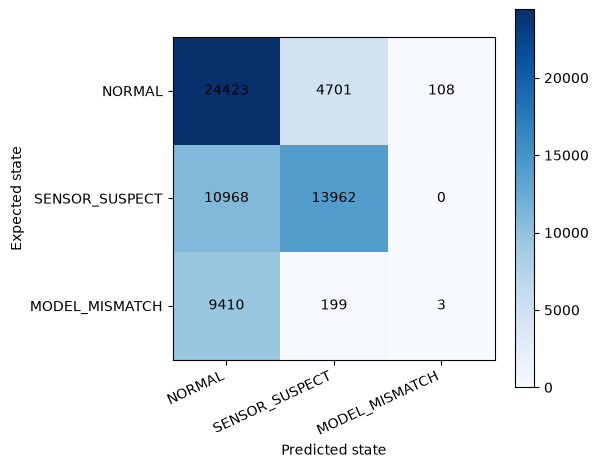

In [10]:
codes = {}
expected = {}
scenario_metric_rows = []
all_expected = []
all_codes = []
for name, scenario in scenarios.items():
    sensor_alarm = (
        (temporal[name]["ewma"] > final_config["tau_ewma"])
        | (temporal[name]["cusum_score"] > final_config["tau_cusum"])
    )
    codes[name] = classify_redesign(sensor_alarm, mismatch[name], final_config["tau_mismatch"])
    active = scenario["active"][:, window_length:]
    expected[name] = np.where(active, scenario["expected_state"], 0).astype(np.int8)
    flagged = codes[name] != 0
    precision, recall, f1, _ = precision_recall_fscore_support(
        expected[name].ravel() != 0,
        flagged.ravel(),
        average="binary",
        zero_division=0,
    )
    active_accuracy = float(np.mean(codes[name][active] == expected[name][active])) if active.any() else None
    clean_mask = (
        np.ones_like(active)
        if name == "clean"
        else np.broadcast_to(target_time < FAULT_START, active.shape)
    )
    recovery_mask = np.broadcast_to(target_time >= FAULT_END, active.shape) if name == "temporary_dropout" else None
    scenario_metric_rows.append(
        {
            "scenario": name,
            "clean_false_alarm_rate": float(np.mean(flagged[clean_mask])),
            "post_recovery_alarm_rate": float(np.mean(flagged[recovery_mask])) if recovery_mask is not None else None,
            "detection_rate": float(np.mean(flagged[active])) if active.any() else None,
            "detection_latency_seconds": detection_latency(flagged, active) if active.any() else None,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "state_accuracy_all": float(np.mean(codes[name] == expected[name])),
            "state_accuracy_active": active_accuracy,
            **{
                f"percent_{state.lower()}": float(100 * np.mean(codes[name] == state_code))
                for state_code, state in enumerate(REDESIGN_STATE_NAMES)
            },
        }
    )
    all_expected.append(expected[name].ravel())
    all_codes.append(codes[name].ravel())

scenario_metrics_df = pd.DataFrame(scenario_metric_rows)
all_expected = np.concatenate(all_expected)
all_codes = np.concatenate(all_codes)
state_confusion = confusion_matrix(all_expected, all_codes, labels=np.arange(3))
global_binary = binary_summary(all_expected != 0, all_codes != 0)
global_state_accuracy = float(np.mean(all_expected == all_codes))
display(scenario_metrics_df.round(4))
print("Global binary metrics:", global_binary)
print("Global state accuracy:", round(global_state_accuracy, 4))

fig, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(state_confusion, cmap="Blues")
axis.set_xticks(range(3), REDESIGN_STATE_NAMES, rotation=25, ha="right")
axis.set_yticks(range(3), REDESIGN_STATE_NAMES)
axis.set_xlabel("Predicted state")
axis.set_ylabel("Expected state")
for row in range(3):
    for column in range(3):
        axis.text(column, row, state_confusion[row, column], ha="center", va="center")
fig.colorbar(image, ax=axis)
fig.tight_layout()
fig.savefig(plots_dir / "reliability_redesign_confusion_matrix.png", dpi=160)
plt.show()

## 10. Ablation study

A uses the saved instantaneous residual threshold. B reproduces the old
residual + N=10 MC-variance flags. C uses only the redesigned temporal sensor
monitor. D adds the multi-step mismatch state with sensor precedence.

,method,false_alarm_rate,detection_rate,precision,recall,f1,clean_only_false_alarm_rate
0,A_instant_residual,0.0157,0.1195,0.8999,0.1195,0.2109,0.0135
1,B_old_residual_plus_mc,0.0381,0.1580,0.8306,0.1580,0.2655,0.0298
2,C_temporal_cusum,0.1608,0.4100,0.7508,0.4100,0.5303,0.0302
3,D_final,0.1645,0.4101,0.7465,0.4101,0.5293,0.0327


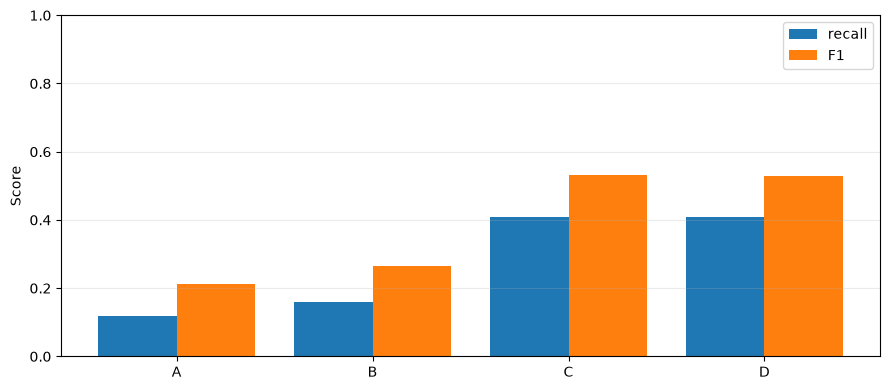

In [11]:
ablation_predictions = {name: [] for name in (
    "A_instant_residual", "B_old_residual_plus_mc", "C_temporal_cusum", "D_final"
)}
ablation_labels = []
clean_predictions = {name: [] for name in ablation_predictions}
for scenario_name, scenario in scenarios.items():
    labels = expected[scenario_name] != 0
    instant = original[scenario_name]["absolute"] > old_config["tau_r"]
    old_combined = instant | (original[scenario_name]["variance"] > old_config["tau_sigma"])
    temporal_only = (
        (temporal[scenario_name]["ewma"] > final_config["tau_ewma"])
        | (temporal[scenario_name]["cusum_score"] > final_config["tau_cusum"])
    )
    predictions = (instant, old_combined, temporal_only, codes[scenario_name] != 0)
    for method, prediction in zip(ablation_predictions, predictions):
        ablation_predictions[method].append(prediction.ravel())
        if scenario_name == "clean":
            clean_predictions[method].append(prediction.ravel())
    ablation_labels.append(labels.ravel())

ablation_labels = np.concatenate(ablation_labels)
ablation_rows = []
for method, prediction_parts in ablation_predictions.items():
    row = {"method": method, **binary_summary(ablation_labels, np.concatenate(prediction_parts))}
    row["clean_only_false_alarm_rate"] = float(np.mean(np.concatenate(clean_predictions[method])))
    ablation_rows.append(row)
ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.round(4))

fig, axis = plt.subplots(figsize=(9, 4))
x = np.arange(len(ablation_df))
axis.bar(x - 0.2, ablation_df["recall"], width=0.4, label="recall")
axis.bar(x + 0.2, ablation_df["f1"], width=0.4, label="F1")
axis.set_xticks(x, ["A", "B", "C", "D"])
axis.set_ylim(0, 1)
axis.set_ylabel("Score")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(plots_dir / "reliability_redesign_ablation.png", dpi=160)
plt.show()

## 11. Approximate CPU cost per control step

The final cost includes one basic guarded prediction, one H-step recursive
forecast, and constant-memory EWMA/CUSUM arithmetic. MC Dropout is timed for
comparison even if rejected.

In [12]:
sample_window = torch.from_numpy(make_windows(base_voltage[0], base_measured[0])[:1])
future_voltage = torch.from_numpy(
    ((base_voltage[0, window_length : window_length + MISMATCH_HORIZON] - input_mean[0]) / input_std[0]).astype(np.float32)
)


def benchmark(function, repetitions):
    for _ in range(5):
        function()
    started = perf_counter()
    for _ in range(repetitions):
        function()
    return 1000 * (perf_counter() - started) / repetitions


@torch.no_grad()
def basic_step():
    model(sample_window)


def mc_step():
    mc_dropout_predict(model, sample_window, passes=10, batch_size=1)


@torch.no_grad()
def multistep_step():
    window = sample_window.clone()
    for step in range(MISMATCH_HORIZON):
        normalized_prediction = model(window)[:, 0]
        physical_prediction = normalized_prediction * target_std + target_mean
        normalized_speed = (physical_prediction - input_mean[1]) / input_std[1]
        next_sample = torch.stack((future_voltage[step : step + 1], normalized_speed), dim=1)
        window = torch.cat((window[:, 1:], next_sample[:, None, :]), dim=1)


def temporal_trace_cost():
    features = temporal_residual_features(guarded["clean"]["residual"][0], ROLLING_WINDOW, EWMA_ALPHA)
    cusum_monitor(features["signed"], guard_cusum["center"], guard_cusum["allowance"], final_config["tau_cusum"])


basic_ms = benchmark(basic_step, 300)
mc_ms = benchmark(mc_step, 50)
multistep_ms = benchmark(multistep_step, 50)
temporal_ms = benchmark(temporal_trace_cost, 100) / guarded["clean"]["residual"].shape[1]
cost_df = pd.DataFrame(
    [
        {"component": "basic_lstm_prediction", "milliseconds_per_step": basic_ms},
        {"component": "mc_dropout_n10", "milliseconds_per_step": mc_ms},
        {"component": "temporal_residual_cusum", "milliseconds_per_step": temporal_ms},
        {"component": "multistep_h15", "milliseconds_per_step": multistep_ms},
        {"component": "final_combined", "milliseconds_per_step": basic_ms + temporal_ms + multistep_ms},
    ]
)
display(cost_df.round(4))

,component,milliseconds_per_step
0,basic_lstm_prediction,0.4015
1,mc_dropout_n10,0.7857
2,temporal_residual_cusum,0.0015
3,multistep_h15,5.9766
4,final_combined,6.3797


## 12. Save preserved redesign outputs and decide MPC readiness

In [13]:
sensor_names = ["gaussian_noise", "small_bias", "large_bias", "gradual_drift", "temporary_dropout"]
model_names = ["load_step", "parameter_variation"]
metric_lookup = scenario_metrics_df.set_index("scenario")
sensor_detection = float(metric_lookup.loc[sensor_names, "detection_rate"].mean())
model_detection = float(metric_lookup.loc[model_names, "detection_rate"].mean())
clean_far = float(metric_lookup.loc["clean", "clean_false_alarm_rate"])
multistep_model_auc = float(mismatch_df.set_index("scenario").loc[model_names, "raw_auc_vs_clean"].mean())
ready_for_mpc = bool(
    clean_far <= 0.05
    and sensor_detection >= 0.80
    and model_detection >= 0.70
    and multistep_model_auc >= 0.70
)

reliable_faults = [
    name for name in sensor_names + model_names
    if metric_lookup.loc[name, "detection_rate"] >= 0.80
    and metric_lookup.loc[name, "state_accuracy_active"] >= 0.70
]
ambiguous_faults = [
    name for name in sensor_names + model_names
    if name not in reliable_faults
]
ambiguous_faults.append("combined_fault: sensor precedence hides concurrent model mismatch")
if metric_lookup.loc["temporary_dropout", "post_recovery_alarm_rate"] > 0.05:
    ambiguous_faults.append("temporary_dropout recovery: CUSUM remains elevated after the sensor returns")

decision = {
    "original_failure": "The residual-output LSTM adds the last measured speed and consumes measured-speed history, so bias/dropout is absorbed after an onset spike; MC variance mainly reacts to noisy inputs and overlaps model-mismatch operation.",
    "improved_sensor_signal": "Guarded predictor feedback plus residual EWMA and clean-calibrated two-sided CUSUM.",
    "mc_dropout_retained": bool(keep_mc_dropout),
    "mc_dropout_model_auc_mean": mc_model_auc,
    "multistep_model_auc_mean": multistep_model_auc,
    "final_architecture": "Provisional three-state monitor: NORMAL, SENSOR_SUSPECT (guarded EWMA/CUSUM), MODEL_MISMATCH (rolling H=15 delayed multi-step error), with sensor precedence; rejected for MPC because the readiness rule fails.",
    "reliably_distinguished": reliable_faults,
    "ambiguous_cases": ambiguous_faults,
    "clean_test_false_alarm_rate": clean_far,
    "mean_sensor_detection_rate": sensor_detection,
    "mean_model_detection_rate": model_detection,
    "ready_for_mpc": ready_for_mpc,
    "readiness_rule": "clean FAR <= 5%, mean sensor detection >= 80%, mean model detection >= 70%, and model-mismatch AUC >= 0.70",
}

metrics_dir = project_root / "results" / "metrics"
configs_dir = project_root / "results" / "configs"
raw_dir = project_root / "results" / "raw"
metrics_dir.mkdir(parents=True, exist_ok=True)
configs_dir.mkdir(parents=True, exist_ok=True)
raw_dir.mkdir(parents=True, exist_ok=True)
diagnosis_df.to_csv(metrics_dir / "reliability_redesign_diagnosis.csv", index=False)
contamination_df.to_csv(metrics_dir / "reliability_input_contamination.csv", index=False)
mc_study_df.to_csv(metrics_dir / "reliability_mc_dropout_study.csv", index=False)
mismatch_df.to_csv(metrics_dir / "reliability_multistep_study.csv", index=False)
calibration_df.to_csv(metrics_dir / "reliability_redesign_calibration.csv", index=False)
scenario_metrics_df.to_csv(metrics_dir / "reliability_redesign_scenario_metrics.csv", index=False)
ablation_df.to_csv(metrics_dir / "reliability_redesign_ablation.csv", index=False)
cost_df.to_csv(metrics_dir / "reliability_redesign_cost.csv", index=False)
pd.DataFrame(
    state_confusion, index=REDESIGN_STATE_NAMES, columns=REDESIGN_STATE_NAMES
).to_csv(metrics_dir / "reliability_redesign_confusion_matrix.csv")
(configs_dir / "reliability_redesign_config.json").write_text(
    json.dumps(final_config, indent=2), encoding="utf-8"
)
(metrics_dir / "reliability_architecture_decision.json").write_text(
    json.dumps(decision, indent=2), encoding="utf-8"
)
(metrics_dir / "reliability_redesign_metrics.json").write_text(
    json.dumps(
        {
            "global_binary": global_binary,
            "global_state_accuracy": global_state_accuracy,
            "scenarios": scenario_metric_rows,
            "decision": decision,
        },
        indent=2,
    ),
    encoding="utf-8",
)

diagnostic_arrays = {
    "scenario_names": np.array(list(scenarios)),
    "state_names": REDESIGN_STATE_NAMES,
    "time": target_time.astype(np.float32),
}
for field, source in (
    ("measured", {name: scenario["measured"][:, window_length:] for name, scenario in scenarios.items()}),
    ("original_residual", {name: original[name]["signed"] for name in scenarios}),
    ("mc_variance", {name: original[name]["variance"] for name in scenarios}),
    ("guarded_prediction", {name: guarded[name]["prediction"] for name in scenarios}),
    ("guarded_residual", {name: guarded[name]["residual"] for name in scenarios}),
    ("residual_ewma", {name: temporal[name]["ewma"] for name in scenarios}),
    ("cusum_positive", {name: temporal[name]["cusum_positive"] for name in scenarios}),
    ("cusum_negative", {name: temporal[name]["cusum_negative"] for name in scenarios}),
    ("mismatch_score", mismatch),
    ("mismatch_score_raw", mismatch_raw),
    ("diagnostic_codes", codes),
    ("expected_codes", expected),
):
    diagnostic_arrays[field] = np.stack([source[name] for name in scenarios])
np.savez_compressed(raw_dir / "reliability_redesign_diagnostics.npz", **diagnostic_arrays)

assert final_config["validation_false_alarm_rate"] <= TARGET_VALIDATION_FAR
assert set(np.unique(diagnostic_arrays["diagnostic_codes"])).issubset({0, 1, 2})
assert (configs_dir / "reliability_redesign_config.json").exists()
assert all((metrics_dir / filename).exists() for filename in (
    "reliability_redesign_metrics.json",
    "reliability_architecture_decision.json",
))
print("Saved redesign artifacts without overwriting Phase-4 outputs.")

Saved redesign artifacts without overwriting Phase-4 outputs.


## 13. Engineering decision

In [14]:
display(
    Markdown(
        f"""
1. **Why the original method failed:** {decision['original_failure']}
2. **Signal that improved bias/drift/dropout detection:** {decision['improved_sensor_signal']}
3. **Keep MC Dropout?** **{decision['mc_dropout_retained']}** (mean model-case AUC {decision['mc_dropout_model_auc_mean']:.3f}).
4. **Final architecture:** {decision['final_architecture']}
5. **Reliably distinguished:** {', '.join(decision['reliably_distinguished']) or 'none at the stated criterion'}.
6. **Ambiguous/failing cases:** {'; '.join(decision['ambiguous_cases'])}.
7. **Clean unseen false-alarm rate:** {decision['clean_test_false_alarm_rate']:.2%}.
8. **Ready to connect to MPC?** **{decision['ready_for_mpc']}**. The fixed readiness rule was: {decision['readiness_rule']}.
"""
    )
)


1. **Why the original method failed:** The residual-output LSTM adds the last measured speed and consumes measured-speed history, so bias/dropout is absorbed after an onset spike; MC variance mainly reacts to noisy inputs and overlaps model-mismatch operation.
2. **Signal that improved bias/drift/dropout detection:** Guarded predictor feedback plus residual EWMA and clean-calibrated two-sided CUSUM.
3. **Keep MC Dropout?** **False** (mean model-case AUC 0.326).
4. **Final architecture:** Provisional three-state monitor: NORMAL, SENSOR_SUSPECT (guarded EWMA/CUSUM), MODEL_MISMATCH (rolling H=15 delayed multi-step error), with sensor precedence; rejected for MPC because the readiness rule fails.
5. **Reliably distinguished:** gaussian_noise, large_bias, temporary_dropout.
6. **Ambiguous/failing cases:** small_bias; gradual_drift; load_step; parameter_variation; combined_fault: sensor precedence hides concurrent model mismatch; temporary_dropout recovery: CUSUM remains elevated after the sensor returns.
7. **Clean unseen false-alarm rate:** 3.27%.
8. **Ready to connect to MPC?** **False**. The fixed readiness rule was: clean FAR <= 5%, mean sensor detection >= 80%, mean model detection >= 70%, and model-mismatch AUC >= 0.70.
